<a href="https://colab.research.google.com/github/Patata-Psyduck/sprint7-final-project/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())# Cantidad de valores nulos)
print(users.isna().mean())# Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:

 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

* La columna City del dataset Users tiene un 11.72% de datos nulos, a pesar de no ser un porcentaje alto, se recomienda verificar bien los datos para determinar cuál es la acción más recomendable para tratarlos.
* La columna Churn_date del dataset Users tiene un 88.35% de datos nulos, maneja el porcentaje más alto del dataset, se pueden eliminar.
* La columna Date del dataset Usage tiene un 0.12% de datos nulos, al ser un porcentaje muy pequeño se podrían tratar de manera puntual los casos o dejarlos nulos.
* La columna Duration del dataset Usage tiene un 55.19% de datos nulos, por el tipo de información que contiene la columna se recomienda investigar su relación con la columna Type y Length para saber cómo tratar estos nulos.
* La columna Length del dataset Usage tiene un 44.74% de datos nulos, por el tipo de información que contiene la columna se recomienda investigar su relación con la columna Type y Duration para saber cómo tratar estos nulos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` el rango de valores es relativamente cercano, por lo que se puede trabajar perfectamente con los datos teniendo buenos resultados y manejo.
- La columna `age` tiene un valor mínimo de -999, lo cual es un nos puede indicar como un valor sentinel.

In [ ]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` tienen diferente número de registros, esto sugiere que un usuario tiene varios registros, por lo que se tienen duplicados.
- Las columnas `id`, `duration`y `length`tienen un valor máximo demaciado alejado al promedio, por lo que se podría tratar de outliers.

In [ ]:
# explorar columnas categóricas de users

columnas_user = ['city', 'plan']
users[columnas_user].describe()


,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` se tienen registro de 7 ciudades, siendo la de mayor consumo Bogotá.
- La columna `plan` se tienen 2 planes, de los cuáles el `Basico` es el más utilizado.

In [ ]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` solo tiene 2 tipos de datos diferentes, siendo el más relevante el tipo `text`.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?


* En el dataset users, dentro de la columna ege, se identifican valores sentinels -999, en esta parte hay que revisar cuantos son los valores que se encuentran dentro de este escenario para confirmar si se pueden conservar así o se puede manejar una altermaniva como eliminar estos datos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce") # completa el código


In [ ]:

# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce") # completa el código


In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date` se tienen registros del 2022 al 2026, no se considera 2025.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date` solo se considera el año 2024, los demás registros se encuentran nulos.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

Por lo que se aprecia, los años considerados son válidos y se puede trabajar con los datos sin problema, sin embargo, se debe verificar la fecha en la que se obtuvo el dataset para asegurar que las fechas del año 2026 sean anteriores a la fecha de obtención de datos, de lo contrario, son fechas inexistetes por aún no haber llegado, estas se podrían tratar como nulas.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:

# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].isin(["?"]).sum()


0

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'] > pd.Timestamp.today(), 'reg_date'] = pd.NaT


# Verificar cambios
(users['reg_date'] > pd.Timestamp.today()).sum()


0

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
missing_duration_by_type = usage["duration"].isna().groupby(usage["type"]).mean()
print(missing_duration_by_type)

type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [ ]:

# Verificación MAR en usage (Missing At Random) para length
missing_length_by_type = usage["length"].isna().groupby(usage["type"]).mean()
print(missing_length_by_type)


type
call    0.99933
text    0.00000
Name: length, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Los nulos en `duration` y `length` si son MAR y dependen fuertemente de la columna `type`, estos valores se deben deja como nulos ya que de no hacerlo se puede alterar el resultado del análisis dando datos con escenarios imaginarios.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.


**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas


2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
                                        total_mensajes=("is_text", "sum"),
                                        total_llamadas=("is_call", "sum"),
                                        total_minutos_llamadas=("duration", "sum")).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,total_mensajes,total_llamadas,total_minutos_llamadas
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg.rename(columns={
                            "total_mensajes": "cant_mensajes",
                            "total_llamadas": "cant_llamadas",
                            "total_minutos_llamadas": "cant_minutos_llamada"
                         }, inplace=True)

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(usage_agg, users, on=['user_id'], how='inner')
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada',
    'age'
]

user_profile[columnas_numericas].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054,48.124531
std,2.358416,2.144238,18.168095,17.692032
min,0.000000,0.000000,0.000000,18.000000
25%,4.000000,3.000000,11.120000,33.000000
50%,5.000000,4.000000,19.780000,47.000000
75%,7.000000,6.000000,31.415000,63.000000
max,17.000000,15.000000,155.690000,79.000000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

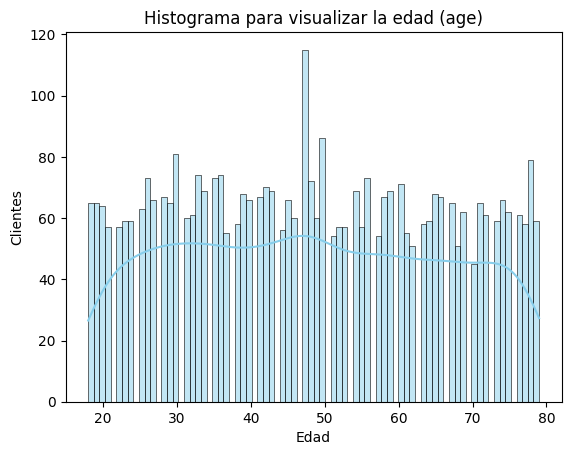

In [ ]:

# Histograma para visualizar la edad (age)
sns.histplot(user_profile['age'], bins=80, color='skyblue', kde=True)

plt.xlabel('Edad')
plt.ylabel('Clientes')
plt.title('Histograma para visualizar la edad (age)')

plt.show()


💡Insights:
- Distribución uniforme entre los 18 y 79 años aproximadamente, marcando solo una concentración mayor alrededor de los 47 años.

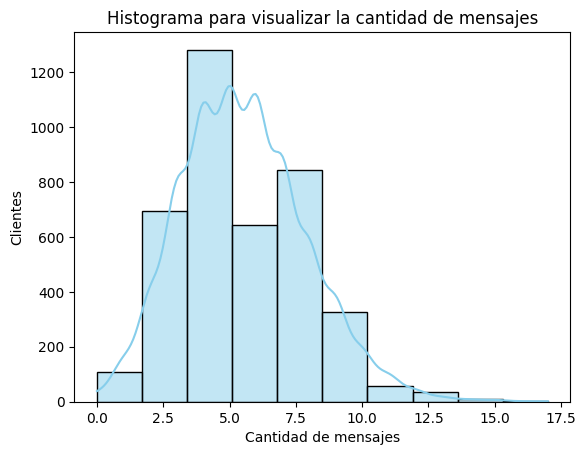

In [ ]:


# Histograma para visualizar la cant_mensajes
sns.histplot(user_profile['cant_mensajes'], bins=10, color='skyblue', kde=True)

plt.xlabel('Cantidad de mensajes')
plt.ylabel('Clientes')
plt.title('Histograma para visualizar la cantidad de mensajes')

plt.show()




💡Insights:
- En el histograma no se visualizan errores.
- La mayoria de los clientes mandan entre 3 y 5 mensajes.
- Se marca sesgo a la derecha.

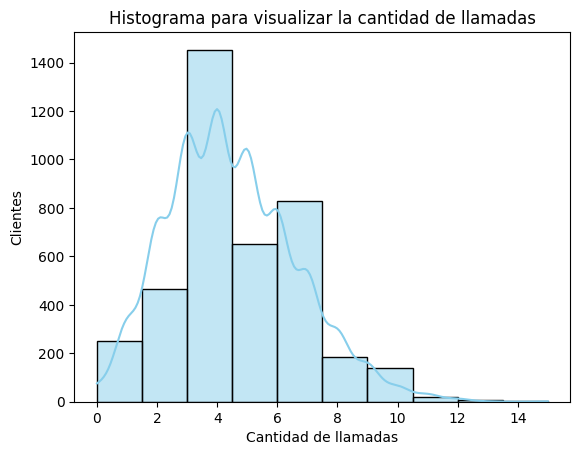

In [ ]:

# Histograma para visualizar la cant_llamadas


sns.histplot(user_profile['cant_llamadas'], bins=10, color='skyblue', kde=True)

plt.xlabel('Cantidad de llamadas')
plt.ylabel('Clientes')
plt.title('Histograma para visualizar la cantidad de llamadas')

plt.show()



💡Insights:
- Distribución es muy similar a la cantidad de mensajes, marca un sesgo a la derecha.
- La mayoría de los clientes realiza entre 3 y 4 llamadas

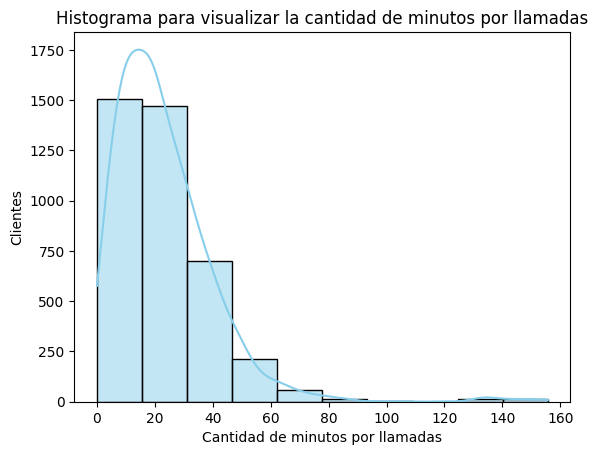

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(user_profile['cant_minutos_llamada'], bins=10, color='skyblue', kde=True)

plt.xlabel('Cantidad de minutos por llamadas')
plt.ylabel('Clientes')
plt.title('Histograma para visualizar la cantidad de minutos por llamadas')

plt.show()

💡Insights:
- El histograma presenta sesgo a la derecha.
- La mayor parte de los clientes realiza llamadas relativamente cortas, no excediendo de 30 minutos.
- Muy pocos clientes registran un ligero aumento en llamadas entre 130–150 minutos, separado de la mayor concentración de datos. Estos podrían ser valores atípicos, aunque sería necesario analizarlos antes de determinar si son errores o valores válidos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

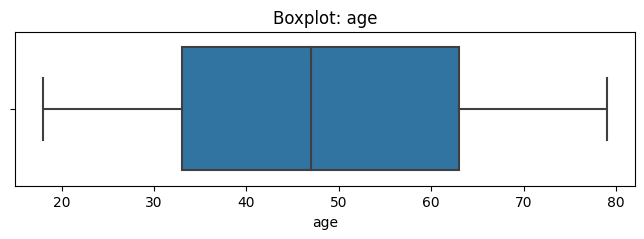

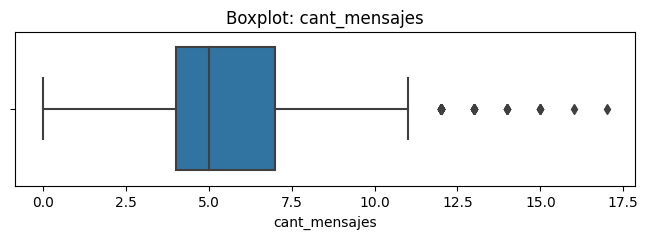

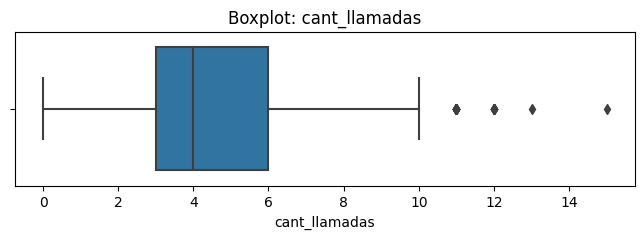

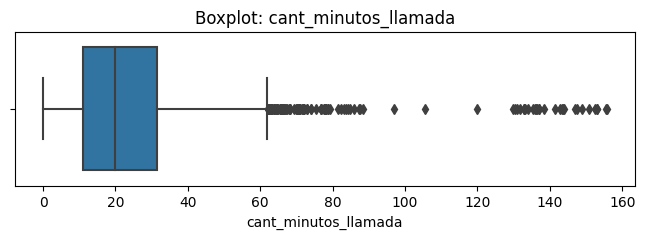

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:
- Age: no presenta outliers, las edades se muestran dentro del rango del boxplot.
- cant_mensajes: sí presenta outliers. Se observan a partir de 12 mensajes, llegando hasta 17 aproximadamente.
- cant_llamadas: sí presenta outliers. Se observan valores entre 11 y 15 llamadas fuera del bigote superior.
- cant_minutos_llamada: sí presenta una cantidad elevada de outliers. Los valores atípicos comienzan aproximadamente después de 60 minutos, y algunos alcanzan cerca de los 160 minutos.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas','cant_minutos_llamada']

for col in columnas_limites:

    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    print(f'{col}:')
    print(f'Límite superior: {limite_superior}')
    print(f'Cantidad de outliers: {(user_profile[col] > limite_superior).sum()}')
    print()

cant_mensajes:
Límite superior: 11.5
Cantidad de outliers: 46

cant_llamadas:
Límite superior: 10.5
Cantidad de outliers: 30

cant_minutos_llamada:
Límite superior: 61.8575
Cantidad de outliers: 109



In [ ]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué?
-- Mantener outliers. El límite superior es 11.5 y el máximo es 17, no están excesivamente alejados y pueden representar usuarios con mayor actividad.
- cant_llamadas: mantener o no outliers, porqué?
-- Mantener outliers. El límite superior es 10.5 y el máximo es 15, la diferencia es moderada y por lo que se visualiza no son generados por error.
- cant_minutos_llamada: mantener o no outliers, porqué?
-- Mantener outliers. El límite superior es 61.86 y el máximo alcanza 155.69, son valores mucho más extremos, pero no hay evidencia de que sean incorrectos y podrían representar usuarios con llamadas de mayor duración.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:

# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where((user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),'Bajo uso',
                                     np.where((user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
                                              'Uso medio','Alto uso'))


In [ ]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(user_profile['age'] < 30,'Joven',
                                      np.where(user_profile['age'] < 60,'Adulto',
                                      'Adulto Mayor'))

In [ ]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

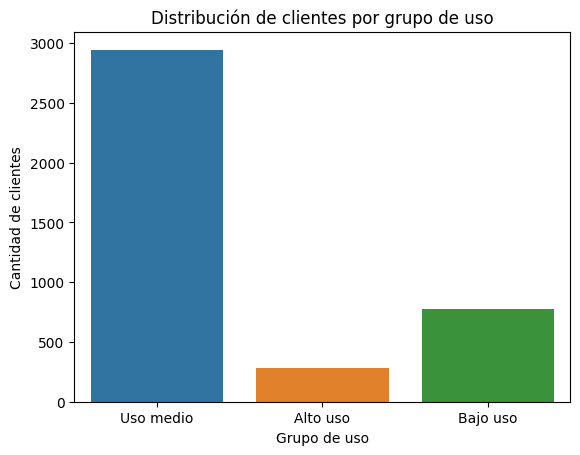

In [ ]:


# Visualización de los segmentos por uso

sns.countplot(data=user_profile,x='grupo_uso')

plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de clientes')
plt.title('Distribución de clientes por grupo de uso')

plt.show()




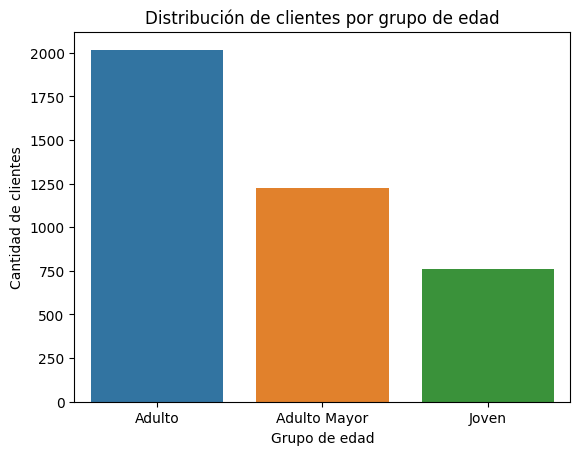

In [ ]:

# Visualización de los segmentos por edad
sns.countplot(data=user_profile,x='grupo_edad')

plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de clientes')
plt.title('Distribución de clientes por grupo de edad')

plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

Se identificaron algunos detalles en los datos:
* En users, la columna age contenía el valor sentinel -999, que no representa una edad válida y fue sustituido por la mediana.
* En city se encontraron valores "?", que fueron tratados como valores nulos.
* La fechas de registro futuras (2026) en reg_date se marcaron como nulas al no ser válidas para el momento en que se generaron los datos.
* En usage, duration y length presentaban una cantidad importante de valores nulos, sin embargo, se comprobó que estos nulos dependen del tipo de servicio, por lo que se conservaron como nulos al representar la estructura natural de los datos.

Para analizar a los clientes se crearon dos tipos de segmentación. Por edad, se clasificaron como Jóvenes (menores de 30 años), Adultos (30 a 59 años) y Adultos Mayores (60 años o más). El grupo más numeroso es el de Adultos, con aproximadamente 2,000 clientes, seguido de Adultos Mayores, con alrededor de 1,200, mientras que los Jóvenes representan el grupo más pequeño, con cerca de 750 clientes. Por nivel de uso, se identificaron clientes de Bajo uso, Uso medio y Alto uso, predomina claramente el Uso medio, con cerca de 3,000 clientes; le sigue el Bajo uso, con alrededor de 800, y finalmente el Alto uso, con aproximadamente 300.

Con la información analizada, se puede determinar que los clientes de Uso medio representan una oportunidad comercial importante debido a que constituyen la mayor parte de la base y podrían aumentar gradualmente su consumo.

El análisis de outliers mostró comportamientos de consumo elevados. En cant_mensajes se identificaron 46 outliers, con un límite superior IQR de 11.5 y un máximo de 17 mensajes. En cant_llamadas se encontraron 30 outliers, con límite de 10.5 y máximo de 15 llamadas. Finalmente, cant_minutos_llamada presentó 109 outliers, con un límite de 61.86 minutos y un máximo de 155.69 minutos. Se decidió conservar estos registros porque no existe evidencia de que sean errores y pueden representar clientes con un uso elevado. Para el negocio, estos usuarios son especialmente interesantes para estudiar patrones de consumo.

A partir de estos resultados, ConnectaTel podría considerar lo siguiente:
* Para los clientes de Bajo uso, podrían evaluarse planes básicos de menor costo que favorezcan su permanencia.
* Para los clientes de Uso medio, podrían diseñarse beneficios que incentiven un mayor consumo y faciliten la migración hacia planes superiores.
* Para clientes de Alto uso, sería conveniente evaluar planes con mayores cantidades de llamadas, minutos y mensajes incluidos, buscando atender su demanda.

La base de clientes de ConnectaTel se concentra principalmente en adultos y usuarios de consumo medio.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- En age se detectaron valores inválidos representados por -999. Estos fueron tratados y sustituidos por la mediana para evitar que afectaran los análisis estadísticos de edad.
- En city se encontraron valores "?", utilizados como indicadores de información faltante, por lo que se reemplazaron por valores nulos.
- En reg_date se identificaron fechas futuras correspondientes a 2026, las cuales fueron consideradas inválidas y se marcaron como valores nulos.
- En duration se encontraron 22,076 valores nulos de 40,000 registros (55.19%) y en length 17,896 (44.74%). Se comprobó que estos faltantes están relacionados con type, por esta razón, se conservaron como nulos, ya que responden a la estructura del registro y no necesariamente a errores de captura.


🔍 **Segmentos por Edad**
- Adultos (30–59 años): constituyen el segmento más numeroso, con aproximadamente 2,000 clientes.
- Adultos Mayores (60 años o más): representan el segundo grupo más grande, con aproximadamente 1,200 clientes.
- Jóvenes (menores de 30 años): son el segmento menos representado, con alrededor de 750 clientes.


📊 **Segmentos por Nivel de Uso**
- Uso medio: es claramente el segmento predominante, con cerca de 3,000 clientes.
- Bajo uso: comprende aproximadamente 800 clientes, que presentan una menor cantidad de llamadas y mensajes.
- Alto uso: es el grupo más pequeño, con aproximadamente 300 clientes, pero concentra usuarios con mayor actividad.
- Se identificaron además 46 outliers en cantidad de mensajes, 30 en cantidad de llamadas y 109 en minutos de llamada. Se decidió conservarlos porque no existe evidencia de que sean errores y pueden representar comportamientos reales de clientes con consumo elevado.


➡️ Esto sugiere que la base de clientes de ConnectaTel está compuesta principalmente por adultos y usuarios de consumo medio. Este grupo representa una oportunidad importante por su tamaño y podría ser objetivo para generar estrategias. Por otro lado, aunque los clientes de alto uso son menos numerosos, sus patrones de actividad justifican analizar sus necesidades por separado.


💡 **Recomendaciones**
- Diseñar ofertas diferenciadas por nivel de consumo: planes sencillos y económicos para Bajo uso, beneficios adicionales o incentivos de crecimiento para Uso medio y planes con mayores cantidades de minutos, llamadas o mensajes para Alto uso.
- Analizar por separado a los usuarios con consumo extremo, especialmente aquellos con más de 61.86 minutos de llamadas, para determinar si existe oportunidad de crear un plan específico para clientes VIP.
- Incorporar información de ingresos, costos o gasto por cliente para determinar cuáles segmentos generan realmente mayor valor económico para ConnectaTel.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`